In [50]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [51]:
# create the state 
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalNumber1: int
    finalNumber2: int

In [52]:
def add_node(state: AgentState) -> AgentState:
    """Add number1 and number2."""
    state['finalNumber1'] = state['finalNumber1'] + state['number1'] + state['number2']
    return state

def substract_node(state: AgentState) -> AgentState:
    """Subtract number2 from finalNumber1."""
    state['finalNumber1'] = state['finalNumber1'] + abs(state['number1'] - state['number2'])
    return state

def add_node2(state: AgentState) -> AgentState:
    """Add number3 and number4."""
    state['finalNumber2'] = state['finalNumber2'] + state['number3'] + state['number4']
    return state

def substract_node2(state: AgentState) -> AgentState:
    """Subtract number3 from finalNumber1."""
    state['finalNumber2'] = state['finalNumber2'] + abs(state['number3'] - state['number4'])
    return state

def router(state: AgentState):
    """Router to decide which operation to perform."""
    if state['operation'] == '+':
        return "addiction_node"
    elif state['operation'] == '-':
        return "substraction_node"
    

def router2(state: AgentState):
    """Router to decide which operation to perform."""
    if state['operation2'] == '+':
        return "addiction_node2"
    elif state['operation2'] == '-':
        return "substraction_node2"

In [54]:
graph = StateGraph(AgentState)
graph.add_node("router", lambda state: state)
graph.add_node("router2", lambda state: state)
graph.add_edge(START, "router")
graph.add_node("addiction_node", add_node)
graph.add_node("substraction_node", substract_node)
graph.add_node("addiction_node2", add_node2)
graph.add_node("substraction_node2", substract_node2)
graph.add_conditional_edges(
    "router",
    router,
    {
        "addiction_node": "addiction_node",
        "substraction_node":  "substraction_node"
    })

graph.add_edge("addiction_node", "router2")
graph.add_edge("substraction_node", "router2")
graph.add_conditional_edges(
    "router2",
    router2,
    {
        "addiction_node2": "addiction_node2",
        "substraction_node2":  "substraction_node2"
    }
)
graph.add_edge("addiction_node2", END)
graph.add_edge("substraction_node2", END)

app = graph.compile()

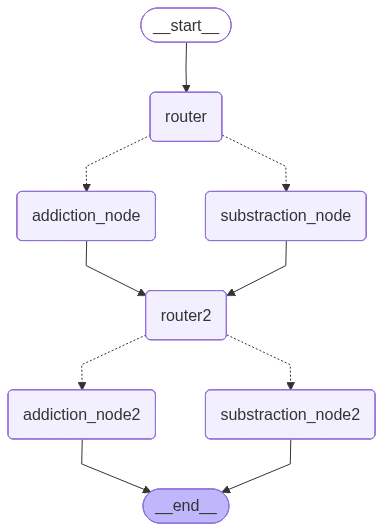

In [55]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [56]:
input_data = AgentState(number1=10, operation="+", number2=5,
                        number3=20, operation2="-", number4=10,
                        finalNumber1=0, finalNumber2=0)
result = app.invoke(input_data)

In [57]:
result['finalNumber1'], result['finalNumber2']

(15, 10)